# TFG Credit Scoring. Caja España
## Notebook 01: Análisis Exploratorio de Datos


 ## 1. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

## 1.1 Introducción al dataset


El presente estudio trabaja con datos históricos reales del año 2010 de la entidad bancaria castellano-leonesa Caja España. El dataset original, FICH_73210_64_JOB.sav, recoge información sobre 73.210 clientes acreditados con préstamos personales, descrita mediante 64 variables que recogen la infomación de cuatro grandes dimensiones subyacentes:

1.  **Relación global:** vínculo general del cliente con la entidad bancaria.
2.  **Productos de pasivo y riesgo:** posiciones de ahorro, inversión y deudas.
3.  **Consumo de servicios:** utilización de productos financieros y servicios de valor añadido.
4.  **Comportamiento histórico:** domiciliación de nóminas, recibos y otros compromisos financieros.

Junto a estas dimensiones descriptivas, el dataset incluye la variable objetivo **CODDEFAULT**, que recoge la calificación de incumplimiento de cada cliente. Del francés défaut (falta, incumplimiento), designa el estado de mora técnica ante incumplimientos superiores a 90 días, conforme a la definición establecida en Basilea II, el acuerdo internacional de regulación bancaria elaborado por el Comité de Supervisión Bancaria de Basilea que fija los criterios de medición del riesgo de crédito y los requisitos de capital de las entidades. El impago (CODDEFAULT) es la variable que el modelo aprenderá a predecir: 0 si el cliente paga, 1 si impaga.

Este estudio no parte del conjunto completo de esas 64 variables, sino de una preselección de 25 variables predictoras previamente depurada por Fernando Mallo, profesor e investigador con estrecha vinculación a Caja España.

Una vez preseleccionadas estas 25 variables de las que parte este trabajo, Fernando Mallo analizó esta misma muestra mediante un modelo de credit scoring en R, cuyo modelo de referencia; una Regresión Logística con 12 predictores, alcanzó sobre la muestra de validación un AUC de 0,9758 y un estadístico de Kolmogórov-Smirnov (KS) de 0,8897, con una tasa de precisión del 98,17%. Estas valores constituyen la referencia de este análisis.

La aportación de este trabajo es triple. En primer lugar, replicar en Python el análisis que Mallo elaboró en R. En segundo lugar, extenderlo con modelos de Machine Learning modernos que él no aplicó, concretamente Random Forest y XGBoost. Y en tercer lugar, aplicar la metodología desarrollada a un dataset público de credit scoring de clientes de Taiwán, demostrando así la capacidad de analizar datos nuevos y de adaptar el enfoque a otros contextos, más allá de la réplica del estudio de Mallo.

## 1.2 Diccionario y significado de las variables predictoras


El dataset queda definido por 25 variables predictoras y la variable objetivo. A continuación se detalla el diccionario de datos: descripción técnica de cada variable e interpretación de negocio para entender qué mide y cómo se relaciona con el riesgo de impago.

| Variable Original | Descripción Técnica | Interpretación de Negocio y Riesgo |
| :--- | :--- | :--- |
| **X3** | Saldo medio en productos de pasivo líquido (últimos 12 meses). | Saldo medio histórico en la cuenta corriente. Mide la liquidez base del cliente. |
| **X5** | Saldo medio en productos de pasivo (últimos 12 meses). | Saldo medio total sumando todas las cuentas y productos de ahorro. |
| **X6** | Importe medio percibido de manera recurrente (últimos 12 meses). | Nivel de ingresos medios constantes (nóminas, pensiones, etc.). |
| **X7** | Saldo mínimo mensual en Pasivo a la Vista (último mes). | El punto de liquidez más bajo alcanzado en la cuenta corriente en el mes reciente. |
| **X8** | Rango mínimo de saldo en Pasivo a la Vista (últimos 12 meses). | **Estabilidad financiera.** Un rango estrecho indica un cliente predecible y ordenado; un rango alto indica fluctuaciones bruscas. |
| **X15** | Importe total a pagar para hacer frente a requerimientos de Activo. | Deuda total exigible y urgente que el cliente debe abonar en el mes actual. |
| **X19** | Máxima antigüedad en el último año en productos de Activo. | **Experiencia crediticia.** Antigüedad del cliente pagando sus préstamos activos recientes. |
| **X20** | Máxima antigüedad en el año en productos de Pasivo. | **Fidelidad.** Tiempo que lleva abierta la cuenta más antigua del cliente en la entidad. |
| **X25** | Mínimo ratio de saldo pendiente frente a importe formalizado (Hipotecas). | Grado de propiedad: porcentaje de la hipoteca original que aún le queda por amortizar. |
| **X26** | Mínimo ratio de saldo pendiente frente a importe formalizado (Personales). | Porcentaje de la deuda original en préstamos personales que aún queda por pagar. |
| **X35** | Número de meses percibiendo ingresos recurrentes (últimos 6 meses). | Estabilidad y recurrencia de los ingresos a corto plazo. |
| **X37** | Número de meses de antigüedad de relación en la Caja. | Antigüedad histórica e ininterrumpida del cliente con el banco. |
| **X42** | Número de recibos básicos cargados en la cuenta (últimos 2 meses). | **Bancarización primaria.** Indica si la entidad es el banco principal donde el cliente domicilia su vida diaria. |
| **X45** | Importe total en productos de Activo (últimos 12 meses). | Deuda media mensual histórica a cargo del cliente en el último año. |
| **X46** | Saldo mínimo mensual medio en Pasivo a la Vista (últimos 6 meses). | **Margen de maniobra.** Indica si el cliente "vive al límite" reteniendo muy poca liquidez a final de mes. |
| **X47** | Cuota máxima de préstamos para financiación a particulares vigentes. | El recibo mensual de mayor importe que el cliente debe afrontar por deudas personales. |
| **X48** | Número de meses con descubierto en Ahorro Vista (últimos 12 meses). | **Alerta de riesgo.** Frecuencia con la que el cliente se ha quedado en "números rojos" en el último año. |
| **X49** | Meses de antigüedad desde el alta en el primer préstamo personal. | Historial crediticio: cuánto tiempo lleva el cliente siendo pagador de préstamos personales. |
| **X53** | Porcentaje de contratos en incidencia sobre el total operativos. | **Historial de morosidad.** Proporción de productos vinculados que presentan retrasos o impagos recientes. |
| **X55** | Ratio de saldo en pasivo no vista frente al pasivo total. | Perfil inversor: porcentaje de los ahorros destinado a productos inmovilizados (fondos, depósitos). |
| **X56** | Ratio de requerimientos de pago totales sobre el saldo en pasivo. | **Tensión de liquidez.** Número de veces que las deudas urgentes superan al dinero disponible en el banco. |
| **X57** | Porcentaje de riesgo en la Caja frente al riesgo total (CIRBE). | Cuota de deuda: qué porcentaje de la deuda total del cliente pertenece a esta entidad frente al resto de bancos. |
| **X58** | Edad del Cliente. | Variable sociodemográfica clásica en scoring. |
| **X63** | Número de recibos no básicos cargados en la cuenta (últimos 3 meses). | **Poder adquisitivo.** El pago de gastos no esenciales (ocio, colegios privados, suscripciones) revela holgura económica. |
| **X64** | Ratio de valor medio de red frente al saldo medio total en pasivo. | Proporción del patrimonio financiero que está invertido y generando valor frente al dinero inmovilizado. |

Se importan las librerías necesarias y se carga el fichero SPSS original, filtrando las 25 variables preseleccionadas y renombrándolas con nombres descriptivos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para los gráficos
sns.set_style("whitegrid")

# CARGA DEL DATASET
df_caja = pd.read_spss('../data/FICH_73210_64_JOB.sav')

# Definición de las 25 variables preseleccionadas + ID + Target
definicion_variables = {
    'NUMACREDIT': 'ID_Cliente',
    'CODDEFAULT': 'Target_Impago',
    'X3': '3_Saldo_Medio_Pasivo_Liq_12m',
    'X5': '5_Saldo_Medio_Pasivo_12m',
    'X6': '6_Ingresos_Recurrentes_12m',
    'X7': '7_Saldo_Min_Pasivo_Vista_1m',
    'X8': '8_Rango_Min_Saldo_Pasivo_12m',
    'X15': '15_Deuda_Activo',
    'X19': '19_Antiguedad_Activo_1a',
    'X20': '20_Antiguedad_Pasivo_1a',
    'X25': '25_Ratio_Hipoteca',
    'X26': '26_Ratio_Prestamo_Personal',
    'X35': '35_Meses_Ingresos_6m',
    'X37': '37_Antiguedad_Banco',
    'X42': '42_Recibos_Basicos_2m',
    'X45': '45_Deuda_Media_12m',
    'X46': '46_Saldo_Min_Medio_Pasivo_6m',
    'X47': '47_Cuota_Max_Prestamos',
    'X48': '48_Meses_Descubierto_12m',
    'X49': '49_Antiguedad_Primer_Prestamo',
    'X53': '53_Porcentaje_Contratos_Incidencia',
    'X55': '55_Ratio_Pasivo_NoVista_Total',
    'X56': '56_Ratio_Pagos_Pasivo',
    'X57': '57_Porcentaje_Riesgo_CIRBE',
    'X58': '58_Edad',
    'X63': '63_Recibos_NoBasicos_3m',
    'X64': '64_Ratio_ValorRed_Pasivo_3m'
}

# Se filtran únicamente esas variables
df_caja_eda = df_caja[list(definicion_variables.keys())].copy()

# Se renombran las columnas
df_caja_eda.rename(columns=definicion_variables, inplace=True)

df_caja_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73210 entries, 0 to 73209
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ID_Cliente                          73210 non-null  float64
 1   Target_Impago                       73210 non-null  float64
 2   3_Saldo_Medio_Pasivo_Liq_12m        73210 non-null  float64
 3   5_Saldo_Medio_Pasivo_12m            73210 non-null  float64
 4   6_Ingresos_Recurrentes_12m          73210 non-null  float64
 5   7_Saldo_Min_Pasivo_Vista_1m         73210 non-null  float64
 6   8_Rango_Min_Saldo_Pasivo_12m        73210 non-null  float64
 7   15_Deuda_Activo                     73210 non-null  float64
 8   19_Antiguedad_Activo_1a             73210 non-null  float64
 9   20_Antiguedad_Pasivo_1a             73210 non-null  float64
 10  25_Ratio_Hipoteca                   73210 non-null  float64
 11  26_Ratio_Prestamo_Personal          73210

## 1.3 Datos faltantes y duplicados


Antes de proceder al entrenamiento de cualquier modelo predictivo, es un requisito metodológico someter el dataset a un control de calidad. Los algoritmos de Machine Learning exigen matrices de datos completas y sin registros duplicados. Por ello, se realizan dos comprobaciones previas:

1. **Detección de registros duplicados:** identificar clientes repetidos que, de existir, introducirían sesgos artificiales durante la fase de aprendizaje al sobreponderar ciertos perfiles.
2. **Cuantificación de valores nulos (NaN):** localizar qué variables presentan vacíos de información para su posterior tratamiento, dado que los modelos matemáticos no pueden operar con datos ausentes.

In [2]:
duplicados = df_caja_eda["ID_Cliente"].duplicated().sum()
print(f"Total de clientes exactamente duplicados: {duplicados}")

nulos = df_caja_eda.isnull().sum()
variables_con_nulos = nulos[nulos > 0]

if variables_con_nulos.empty:
    print("No hay ningún dato faltante.")
else:
    print("Variables con datos vacíos")
    print(variables_con_nulos)


Total de clientes exactamente duplicados: 0
Variables con datos vacíos
46_Saldo_Min_Medio_Pasivo_6m     30729
47_Cuota_Max_Prestamos             975
49_Antiguedad_Primer_Prestamo    44751
55_Ratio_Pasivo_NoVista_Total    31487
56_Ratio_Pagos_Pasivo            31487
dtype: int64


El análisis de valores nulos revela la ausencia de información en cinco variables predictoras. En el contexto bancario, estos vacíos no representan errores de registro informático, sino que indican la no tenencia del producto financiero asociado por parte del cliente.

-   **Antigüedad del primer préstamo (44.751 nulos, el 61,1% de la muestra):** es la variable con mayor ausencia de datos, afectando a más de la mitad de los individuos del dataset. Esto significa que más de la mitad de los clientes de la base de datos nunca han formalizado un préstamo con garantía personal en la entidad y, por tanto, carecen de una fecha de alta desde la que calcular su antigüedad.

-   **Ratio Pasivo No Vista y Ratio Pagos Pasivo (31.487 nulos cada una):** la coincidencia exacta en el número de nulos no es casual, ya que ambas variables comparten el mismo denominador: el Pasivo Total del cliente. La primera mide qué porcentaje de los ahorros totales está invertido en productos inmovilizados (depósitos, fondos de inversión o planes de pensiones). La segunda mide cuántas veces las deudas urgentes superan al dinero disponible en el banco. Estos valores nulos indican que 31.487 clientes tienen 0 € en su pasivo total; es decir, utilizan el banco únicamente como prestamista, sin mantener saldo en cuenta corriente ni en productos de ahorro o inversión. Al ser el Pasivo Total igual a 0 € y actuar como denominador, el cálculo de ambas variables resulta matemáticamente indefinido:

$$X_{55} \text{ Ratio Pasivo No Vista} = \frac{\text{Saldo Invertido}}{\text{Pasivo Total}}$$
$$X_{56} \text{ Ratio Pagos Pasivo} = \frac{\text{Requerimiento De Pago}}{\text{Pasivo Total}}$$

-   **Saldo Mínimo Pasivo a la Vista, últimos 6 meses (30.729 nulos):** corresponde a clientes que no han mantenido saldo en su cuenta corriente durante el semestre analizado. Es relevante que esta cifra sea ligeramente inferior a la de X55 y X56 (30.729 frente a 31.487). La razón es que un cliente puede tener 0 € en el mes de observación, lo que deja sin denominador a los ratios, y haber mantenido saldo en meses anteriores; en ese caso, X46 sí dispone de un valor histórico computable.

-   **Cuota Máxima de Préstamos (975 nulos, el 1,3% de la muestra):** representa una fracción minoritaria de clientes que, en el momento de la extracción de los datos, no tienen ningún préstamo vigente que genere una cuota exigible.

## 1.4 Tratamiento de datos faltantes


Tras identificar que la ausencia de datos en estas cinco variables responde a la lógica de negocio y no a un error informático, conviene precisar a qué se debe: el dato falta porque el cliente no tiene contratado el producto financiero correspondiente. Es, por tanto, una ausencia estructural o por diseño (Little y Rubin, 1987), consecuencia directa de un hecho ya conocido sobre el cliente.

Aplicar técnicas de imputación estadísticas tradicionales, como la media, la mediana o algoritmos predictivos, supondría un error metodológico grave, ya que implicaría inventar saldos o deudas artificiales para clientes que no tienen contratado dicho producto. Por otro lado, imputar un valor atípico como -1 en variables numéricas continuas puede distorsionar el aprendizaje de los algoritmos de Machine Learning.

Para resolver esta ausencia de información de manera robusta y extraer el máximo valor predictivo, se aplica una técnica combinada de Feature Engineering:

-   **Creación de Variables Indicadoras (Flags):** se generan nuevas columnas binarias (1 = sin producto, 0 = con producto) que capturan explícitamente si el cliente carece del producto. De este modo, la ausencia de información se convierte en un nuevo patrón analítico que el modelo puede interpretar como un factor de riesgo en sí mismo.

-   **Imputación Neutra con Criterio de Negocio:** una vez que la ausencia de producto queda registrada en los Flags del paso anterior, los valores nulos originales se sustituyen por 0. La justificación varía según el tipo de variable.


**Variables monetarias y proporciones (X46, X47, X55, X56):** en estos casos el razonamiento es directo. Si un cliente no tiene ningún préstamo activo, su cuota mensual exigible es 0; si no mantiene saldo en cuenta, su ratio de inversión y su ratio de presión de deuda son también 0. La imputación reproduce la situación económica real del cliente:

| Cliente | X47 original (cuota préstamo) | Flag_Sin_Prestamo | X47 imputada |
| :---: | :---: | :---: | :---: |
| A | 250 | 0 | 250 |
| B | NaN | 1 | 0 |
| C | 180 | 0 | 180 |
| D | NaN | 1 | 0 |

**Variable temporal (X49, Antigüedad del Primer Préstamo):** esta variable exige una justificación adicional, porque a diferencia de las monetarias, el valor 0 es ambiguo por sí mismo una antigüedad de 0 meses puede significar dos cosas opuestas: que el cliente no tiene ningún historial crediticio, o que formalizó su primer préstamo justo en el mes de observación. Imputar 0 a los nulos sin más confundiría ambos perfiles.

El Flag resuelve esta ambigüedad al actuar como separador. Cuando Flag_Sin_Primer_Prestamo vale 1, el 0 de la columna *X49 imputada* se interpreta como ausencia total de historial; cuando vale 0, ese mismo 0 corresponde a un préstamo recién formalizado. Así, el modelo distingue dos situaciones que, sin el Flag, serían indistinguibles:

| Cliente | X49 original | Flag_Sin_Primer_Prestamo | X49 imputada |
| :---: | :---: | :---: | :---: |
| A | 24 | 0 | 24 |
| B | NaN | 1 | 0 |
| C | 0 | 0 | 0 |
| D | NaN | 1 | 0 |

El cliente C tiene X49 = 0 de forma natural (préstamo formalizado este mes). El cliente D también termina con X49 = 0 tras la imputación (nunca ha tenido préstamo). Sin el Flag, el modelo los trataría como perfiles idénticos; con el Flag, los distingue sin ambigüedad.

Este enfoque de Feature Engineering difiere del aplicado por Fernando Mallo, que transformó estas cinco variables mediante WoE-binning (Weight of Evidence), sustituyendo cada intervalo; incluido el de valores nulos, por un valor numérico proporcional a la tasa de buenos y malos del grupo. El WoE está optimizado para la Regresión Logística, porque linealiza la relación entre cada variable y el target, que es justo lo que un modelo lineal necesita para ajustar bien.

La estrategia de Flags con imputación neutra responde a una lógica distinta. Como este trabajo extiende el análisis a modelos basados en árboles (Random Forest y XGBoost), que aprenden relaciones no lineales por sí mismos y manejan los patrones de ausencia sin necesidad de linealizarlos, los Flags resultan más eficientes: cada algoritmo explota la variable binaria directamente como un factor de riesgo adicional.

La decisión, por tanto, no consiste en sustituir la técnica de Mallo por otra más sencilla, sino en aplicar a cada modelo el preprocesamiento que mejor le conviene. De hecho, este estudio incorpora también la transformación WoE en el notebook dedicado a la Regresión Logística, precisamente para tratar ese modelo lineal en su terreno óptimo y compararlo de igual a igual con el de Mallo. En definitiva, cada modelo se entrena con la transformación que mejor se ajusta a su naturaleza: WoE para la Regresión Logística y Flags para Random Forest y XGBoost.

In [3]:
# CREACIÓN DE VARIABLES INDICADORAS (antes de imputar, mientras los nulos siguen presentes)
# 1 si el dato original era nulo (cliente sin el producto), 0 si lo tenía.
df_caja_eda['Flag_Sin_Primer_Prestamo'] = df_caja_eda['49_Antiguedad_Primer_Prestamo'].isnull().astype(int)
df_caja_eda['Flag_Sin_Pasivo_6m']      = df_caja_eda['46_Saldo_Min_Medio_Pasivo_6m'].isnull().astype(int)
df_caja_eda['Flag_Sin_Pasivo_NoVista'] = df_caja_eda['55_Ratio_Pasivo_NoVista_Total'].isnull().astype(int)
df_caja_eda['Flag_Sin_Prestamo'] = df_caja_eda['47_Cuota_Max_Prestamos'].isnull().astype(int)
df_caja_eda['Flag_Sin_Ratio_Pagos']    = df_caja_eda['56_Ratio_Pagos_Pasivo'].isnull().astype(int)
# Nota: Flag_Sin_Pasivo_NoVista y Flag_Sin_Ratio_Pagos son idénticos (X55 y X56 comparten denominador),
# pero se mantienen separados para preservar la correspondencia uno a uno con cada variable original.

# IMPUTACIÓN NEUTRA DE LOS NULOS ORIGINALES
valores_imputacion = {
    '46_Saldo_Min_Medio_Pasivo_6m':  0,
    '47_Cuota_Max_Prestamos':         0,
    '49_Antiguedad_Primer_Prestamo':  0,
    '55_Ratio_Pasivo_NoVista_Total':  0,
    '56_Ratio_Pagos_Pasivo':          0,
}
df_caja_eda.fillna(value=valores_imputacion, inplace=True)

# COMPROBACIÓN DE RESULTADOS
print(f"Nulos restantes tras la imputación: {df_caja_eda.isnull().sum().sum()}")
print(f"Dimensiones finales (27 columnas originales + 5 Flags): {df_caja_eda.shape}")

Nulos restantes tras la imputación: 0
Dimensiones finales (27 columnas originales + 5 Flags): (73210, 32)


## 1.5 Balance de la variable target: impago


A continuación se analiza la distribución de la variable objetivo para cuantificar el grado de desbalanceo entre clientes buenos y malos.

La proporción de impagos es (0 SI pagado), (1 NO pagado):  Target_Impago
0.0    92.475072
1.0     7.524928
Name: proportion, dtype: float64


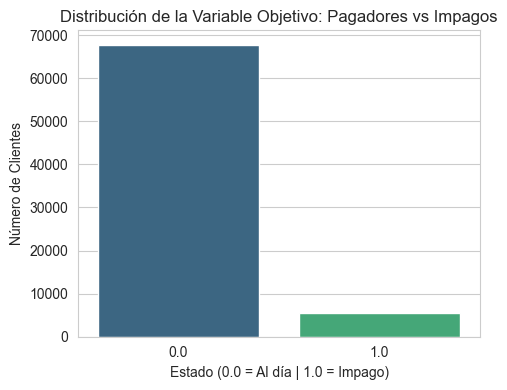

In [4]:
# ANÁLISIS DE LA VARIABLE TARGET IMPAGO
distribucion = df_caja_eda['Target_Impago'].value_counts(normalize=True) * 100
print("La proporción de impagos es (0 SI pagado), (1 NO pagado): ", distribucion)

# gráfico de desbalanceo
plt.figure(figsize=(5, 4))
sns.countplot(data=df_caja_eda, x='Target_Impago', hue='Target_Impago', palette='viridis', legend=False)
plt.title("Distribución de la Variable Objetivo: Pagadores vs Impagos")
plt.xlabel("Estado (0.0 = Al día | 1.0 = Impago)")
plt.ylabel("Número de Clientes")
plt.tight_layout()
plt.savefig("../reports/figures/01_distribucion_target.png", dpi=150, bbox_inches="tight")
plt.show()

El estudio de la variable objetivo es uno de los pasos centrales del análisis exploratorio, porque su comportamiento condiciona buena parte de las decisiones de modelado posteriores. El gráfico revela cómo se reparten los clientes entre las dos clases:

- Clase 0, pagadores: 92.47%
- Clase 1, morosos: 7.52%

Por cada cliente que impaga hay aproximadamente doce que cumplen con sus obligaciones. Lejos de ser una peculiaridad de estos datos, es la situación habitual en riesgo de crédito, donde el impago constituye un evento minoritario.

Esta asimetría afecta negativamente el aprendizaje automático, ya que un modelo entrenado sobre una distribución tan desigual tiende a desentenderse de la clase minoritaria, que es justamente la que interesa detectar. Cómo afecta esto al entrenamiento y, sobre todo, de qué manera se corrige se aborda en el notebook 02, mediante un oversampling estratificado que replica la metodología de Mallo.

## 1.6 Análisis de correlación con la variable objetivo


Para cuantificar objetivamente la relación de cada variable con el riesgo de impago se calcula la correlación de Pearson entre cada predictor y Target_Impago. En modelos de credit scoring, las correlaciones individuales son típicamente moderadas (entre 0.10 y 0.30), sumado al desbalanceo de clases (7.52% de morosos) y la naturaleza multifactorial del riesgo crediticio hacen que el impago dependa de múltiples señales conjuntas. Dentro de este contexto, las variables con mayor correlación en valor absoluto son las más informativas para separar a buenos y malos pagadores, mientras que las próximas a 0 contribuyen poco a la predicción.

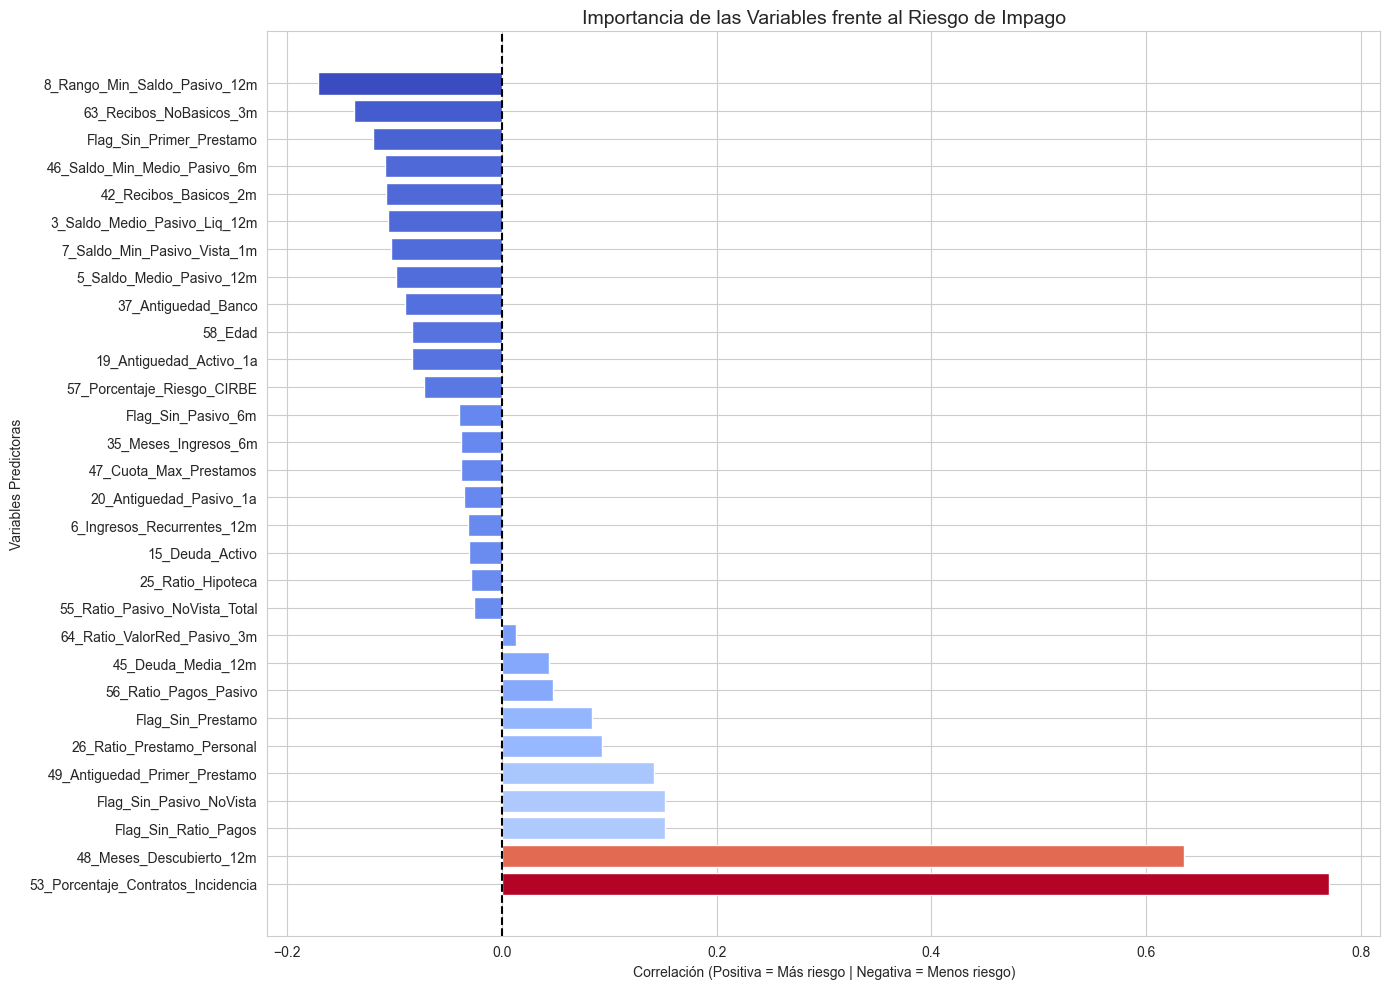

In [5]:
# CORRELACIÓN DE VARIABLES CON EL IMPAGO
import matplotlib.cm as cm
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(14, 10))

# Cálculo de correlaciones con el target (excluyendo ID)
corr_con_target = (
    df_caja_eda.drop('ID_Cliente', axis=1)
    .corr()['Target_Impago']
    .drop('Target_Impago')
    .sort_values(ascending=False)
)

# Colores en gradiente coolwarm según valor (evita el uso deprecado de hue continuo en seaborn)
norm = mcolors.Normalize(vmin=corr_con_target.min(), vmax=corr_con_target.max())
colors = cm.coolwarm(norm(corr_con_target.values))

ax.barh(corr_con_target.index, corr_con_target.values, color=colors)
ax.set_title('Importancia de las Variables frente al Riesgo de Impago', fontsize=14)
ax.set_xlabel('Correlación (Positiva = Más riesgo | Negativa = Menos riesgo)')
ax.set_ylabel('Variables Predictoras')
ax.axvline(x=0, color='black', linestyle='--')

plt.tight_layout()
plt.savefig("../reports/figures/01_correlacion_variables_target.png", dpi=150, bbox_inches="tight")
plt.show()

El análisis de correlaciones valida empíricamente la estrategia de Feature Engineering aplicada en la sección anterior. Al crear indicadores binarios para los datos faltantes, la ausencia de producto deja de ser un vacío invisible y se convierte en una señal explícita que el modelo puede interpretar.

El gráfico muestra las correlaciones de Pearson de las 30 variables (25 originales + 5 Flags) con Target_Impago, ordenadas de mayor a menor. Se distinguen dos grupos: predictores que elevan el riesgo de impago (correlación positiva, tonos rojos) y predictores que lo reducen (correlación negativa, tonos azules).

**Dos variables exigen una lectura aparte, antes de comentar el resto:**

- **53_Porcentaje_Contratos_Incidencia** (r = +0.77): mide el porcentaje de contratos del cliente que presentan incidencias registradas en el mes actual, es decir, retrasos o cuotas impagadas en ese mismo periodo. Este valor se aleja, en un orden de magnitud, del rango 0,10-0,30 que esta misma sección ha señalado como habitual en credit scoring. Una correlación tan extrema no es necesariamente la marca de un buen predictor: puede ser, en cambio, el síntoma de que la variable está midiendo casi el mismo fenómeno que el target, en el mismo instante en que se mide. X53 se reexamina con detalle en el notebook 03 antes de aceptarla en los modelos definitivos.
- **48_Meses_Descubierto_12m** (r = +0.63): registra cuántos meses de los últimos doce el cliente ha mantenido saldo negativo en su cuenta corriente. También se sitúa muy por encima del rango habitual, y describe igualmente un comportamiento de impago ya manifestado más que un factor de riesgo anterior al impago. Se somete a la misma revisión que X53 en el notebook 03.

**Variables asociadas a menor riesgo (correlación negativa):**

- **8_Rango_Min_Saldo_Pasivo_12m** (r = -0.17): mide la diferencia entre el saldo máximo y el mínimo de la cuenta corriente a lo largo de los últimos 12 meses. Un rango amplio indica que el cliente recibe ingresos regulares (que elevan el saldo) y tiene actividad financiera normal (que lo reduce), lo que refleja una dinámica económica sana. Por el contrario, un rango reducido puede señalar que el saldo se mantiene siempre cerca de cero o en negativo, con escaso margen para absorber nuevas obligaciones de pago.

- **63_Recibos_NoBasicos_3m** (r = -0.14): cuenta el número de recibos de gastos no esenciales (seguros voluntarios, colegios privados, suscripciones a servicios, etc ...) domiciliados en los últimos 3 meses. Solo quienes disponen de holgura económica pueden permitirse estos compromisos de forma regular. Además, mantener estos pagos al día refleja disciplina financiera y ausencia de apuros de liquidez, características que reducen el riesgo de impago.

- **Flag_Sin_Prestamo** (r = -0.12): indica que el cliente no tiene ningún préstamo activo en el momento de la observación (X47 sin cuota exigible). Al no arrastrar obligaciones crediticias vigentes, dispone de toda su capacidad de pago disponible, lo que se traduce en un riesgo de impago inferior al de clientes con deuda mensual activa.

Entre las variables de correlación positiva moderada, destaca también **Flag_Sin_Pasivo_NoVista** (r = +0.15), de los cinco Flags creados el que muestra mayor asociación con el riesgo. Identifica a los clientes cuyo pasivo total es nulo, esto es, que no mantienen saldo alguno en la entidad (ni en cuenta corriente ni en productos de ahorro o inversión) y la utilizan únicamente como prestamista. Al carecer de colchón financiero y de patrimonio acumulado, este perfil dispone de menor margen para afrontar imprevistos y nuevas obligaciones crediticias, lo que explica su mayor riesgo de impago.

## 1.7 Síntesis del análisis exploratorio

Las secciones anteriores permiten extraer tres conclusiones que condicionan el diseño metodológico del resto del estudio.

**El Feature Engineering resulta empíricamente válido.** De los cinco Flags creados, dos muestran asociación apreciable con el target: Flag_Sin_Pasivo_NoVista (r = +0.15) y Flag_Sin_Prestamo (r = -0.12). Que indicadores binarios de ausencia de producto aparezcan entre las variables más informativas confirma que la ausencia de datos tiene valor predictivo propio.

**El desbalanceo de clases es el principal condicionante de la modelización.** Con un 92.47% de pagadores frente a un 7.52% de morosos (ratio 12.28:1), un modelo entrenado directamente sobre esta distribución tendería a ignorar la clase de interés. El tratamiento mediante oversampling estratificado se aborda en el notebook 02.

**X53 y X48 rompen el patrón multifactorial esperado y deben verificarse antes de modelizar.** Con la salvedad de X53 (r = +0.77) y X48 (r = +0.63), el resto de las variables opera en el rango moderado típico del credit scoring (0.10-0.20), lo que es compatible con que el impago dependa de la combinación de múltiples señales y no de una sola causa. X53 y X48 quedan, en cambio, muy por encima de ese rango: una correlación tan alta es más propia de una variable que ya contiene parte de la respuesta que se pretende predecir que de un factor de riesgo independiente. Antes de aceptarlas en los modelos definitivos, el notebook 03 contrasta esta sospecha reentrenando sin X53 y sin X53 ni X48, y decide en consecuencia qué conjunto de variables emplear en el resto del estudio.

| Concepto | Valor |
|----------|-------|
| Observaciones | 73.210 clientes |
| Variables predictoras originales | 25 |
| Variables indicadoras (Flags) creadas | 5 |
| **Total de columnas (con ID y Target)** | **32** |
| Valores nulos restantes | 0 |
| Clientes buenos (Target = 0) | 67.701 (92.47%) |
| Clientes morosos (Target = 1) | 5.509 (7.52%) |
| Ratio de desbalanceo | 12.28:1 |

El dataset está completamente preparado para el notebook 02, donde se aplicará el oversampling estratificado y la partición train/val/test.

A continuación se imprime la síntesis ejecutiva con los hallazgos clave del EDA: distribución del target, validación de los Flags creados y los cinco predictores con mayor correlación con el impago.

In [6]:
# RESUMEN EJECUTIVO: HALLAZGOS DEL EDA
print("=" * 80)
print("SÍNTESIS DEL ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("=" * 80)

print("\n1. ESTADO FINAL DEL DATASET")
print(f"   - Observaciones: {df_caja_eda.shape[0]:,} clientes")
print(f"   - Variables predictoras: {df_caja_eda.shape[1] - 2} (25 originales + 5 Flags)")
print(f"   - Valores nulos: {df_caja_eda.isnull().sum().sum()} (100% limpio)")

print("\n2. DISTRIBUCIÓN DEL TARGET (IMPAGO)")
target_counts = df_caja_eda['Target_Impago'].value_counts()
target_pct = df_caja_eda['Target_Impago'].value_counts(normalize=True) * 100
print(f"   - Pagadores (0): {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"   - Morosos (1): {target_counts[1]:,} ({target_pct[1]:.2f}%)")
print(f"   - Ratio de desbalanceo: {target_counts[0]/target_counts[1]:.2f}:1")

print("\n3. VALIDACIÓN DE FEATURE ENGINEERING")
flags = [col for col in df_caja_eda.columns if col.startswith('Flag_')]
print(f"   - Flags creados: {len(flags)}")
for flag in flags:
    count = df_caja_eda[flag].sum()
    pct = (count / len(df_caja_eda)) * 100
    print(f"     - {flag}: {count:,} clientes ({pct:.2f}%)")

print("\n4. PREDICTORES MÁS FUERTES")
corr_abs = corr_con_target.abs().sort_values(ascending=False)
print("   Top 5 variables por correlación absoluta con target:")
for i, (var, corr) in enumerate(corr_con_target.sort_values(ascending=False).head(5).items(), 1):
    direction = "RIESGO ↑" if corr > 0 else "RIESGO ↓"
    print(f"   {i}. {var}: {corr:+.3f} {direction}")

print("\n5. PREREQUISITOS PARA MODELIZACIÓN (NOTEBOOK 02)")
print("   => Dataset completamente preparado")
print("   => Tratamiento de nulos finalizado (Flags + imputación)")
print("   => Análisis de correlaciones validado")
print("   => Próximos pasos: oversampling estratificado, particionamiento train/val/test")
print("=" * 80)

SÍNTESIS DEL ANÁLISIS EXPLORATORIO DE DATOS (EDA)

1. ESTADO FINAL DEL DATASET
   - Observaciones: 73,210 clientes
   - Variables predictoras: 30 (25 originales + 5 Flags)
   - Valores nulos: 0 (100% limpio)

2. DISTRIBUCIÓN DEL TARGET (IMPAGO)
   - Pagadores (0): 67,701 (92.48%)
   - Morosos (1): 5,509 (7.52%)
   - Ratio de desbalanceo: 12.29:1

3. VALIDACIÓN DE FEATURE ENGINEERING
   - Flags creados: 5
     - Flag_Sin_Primer_Prestamo: 44,751 clientes (61.13%)
     - Flag_Sin_Pasivo_6m: 30,729 clientes (41.97%)
     - Flag_Sin_Pasivo_NoVista: 31,487 clientes (43.01%)
     - Flag_Sin_Prestamo: 975 clientes (1.33%)
     - Flag_Sin_Ratio_Pagos: 31,487 clientes (43.01%)

4. PREDICTORES MÁS FUERTES
   Top 5 variables por correlación absoluta con target:
   1. 53_Porcentaje_Contratos_Incidencia: +0.771 RIESGO ↑
   2. 48_Meses_Descubierto_12m: +0.635 RIESGO ↑
   3. Flag_Sin_Ratio_Pagos: +0.152 RIESGO ↑
   4. Flag_Sin_Pasivo_NoVista: +0.152 RIESGO ↑
   5. 49_Antiguedad_Primer_Prestamo: +0.141

## 1.8 Guardado del dataset procesado

Se exporta el dataset limpio (25 variables + 5 Flags + Target_Impago) para su uso directo en el notebook 02. El fichero SPSS original no se modifica.


In [7]:
# Se seleccionan las columnas del modelo (sin ID_Cliente)
cols_modelo = [c for c in df_caja_eda.columns if c != "ID_Cliente"]
df_guardar = df_caja_eda[cols_modelo].copy()

# Convertir tipos no serializables del SPSS a tipos estándar
for col in df_guardar.columns:
    if col == "Target_Impago" or col.startswith("Flag_"):
        df_guardar[col] = df_guardar[col].astype(int)
    else:
        df_guardar[col] = pd.to_numeric(df_guardar[col], errors="coerce").astype(float)

df_guardar.to_csv("../data/01_dataset_limpio.csv", index=False)

print(f"Dataset guardado: {df_guardar.shape[0]:,} filas x {df_guardar.shape[1]} columnas")
print("Ruta: data/01_dataset_limpio.csv")
print(f"Columnas: {list(df_guardar.columns)}")

Dataset guardado: 73,210 filas x 31 columnas
Ruta: data/01_dataset_limpio.csv
Columnas: ['Target_Impago', '3_Saldo_Medio_Pasivo_Liq_12m', '5_Saldo_Medio_Pasivo_12m', '6_Ingresos_Recurrentes_12m', '7_Saldo_Min_Pasivo_Vista_1m', '8_Rango_Min_Saldo_Pasivo_12m', '15_Deuda_Activo', '19_Antiguedad_Activo_1a', '20_Antiguedad_Pasivo_1a', '25_Ratio_Hipoteca', '26_Ratio_Prestamo_Personal', '35_Meses_Ingresos_6m', '37_Antiguedad_Banco', '42_Recibos_Basicos_2m', '45_Deuda_Media_12m', '46_Saldo_Min_Medio_Pasivo_6m', '47_Cuota_Max_Prestamos', '48_Meses_Descubierto_12m', '49_Antiguedad_Primer_Prestamo', '53_Porcentaje_Contratos_Incidencia', '55_Ratio_Pasivo_NoVista_Total', '56_Ratio_Pagos_Pasivo', '57_Porcentaje_Riesgo_CIRBE', '58_Edad', '63_Recibos_NoBasicos_3m', '64_Ratio_ValorRed_Pasivo_3m', 'Flag_Sin_Primer_Prestamo', 'Flag_Sin_Pasivo_6m', 'Flag_Sin_Pasivo_NoVista', 'Flag_Sin_Prestamo', 'Flag_Sin_Ratio_Pagos']
